In [186]:
import random
from time import time

In [187]:
def parse_instance(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Remove empty lines
    lines = [line.strip() for line in lines if line.strip()]

    # Find line with "jobs machines"
    for i, line in enumerate(lines):
        if line[0].isdigit():
            jobs, machines = map(int, line.split())
            start_index = i + 1
            break

    jobs_data = []

    for line in lines[start_index:start_index + jobs]:
        numbers = list(map(int, line.split()))
        operations = []
        for i in range(0, len(numbers), 2):
            machine = numbers[i]
            duration = numbers[i + 1]
            operations.append((machine, duration))
        jobs_data.append(operations)

    return jobs, machines, jobs_data

In [188]:
class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = None


def generate_chromosome(num_jobs, num_machines):
    chromosome = []
    for job in range(num_jobs):
        chromosome += [job] * num_machines
    random.shuffle(chromosome)
    return chromosome

In [189]:
def compute_makespan(chromosome, jobs_data):
    num_jobs = len(jobs_data)
    num_machines = len(jobs_data[0])

    job_next_op = [0] * num_jobs
    job_end_time = [0] * num_jobs
    machine_end_time = [0] * num_machines

    for job in chromosome:
        op_index = job_next_op[job]
        machine, duration = jobs_data[job][op_index]

        start_time = max(job_end_time[job], machine_end_time[machine])
        end_time = start_time + duration

        job_end_time[job] = end_time
        machine_end_time[machine] = end_time
        job_next_op[job] += 1

    return max(job_end_time)

def population_fitness_sort(population, jobs_data):
    for ind in population:
        ind.fitness = compute_makespan(ind.chromosome, jobs_data)

    population.sort(key=lambda x: x.fitness)
    return population


In [190]:

def tournament_selection(population, k=3):
    contenders = random.sample(population, k)
    contenders.sort(key=lambda x: x.fitness)
    return contenders[0]

def crossover(parent1, parent2, num_jobs, num_machines):
    size = len(parent1.chromosome)

    a, b = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[a:b] = parent1.chromosome[a:b]

    required_count = {job: num_machines for job in range(num_jobs)}

    for gene in child[a:b]:
        required_count[gene] -= 1

    fill_index = 0
    for gene in parent2.chromosome:
        if required_count[gene] > 0:
            while child[fill_index] is not None:
                fill_index += 1
            child[fill_index] = gene
            required_count[gene] -= 1

    return Individual(child)

def mutate(individual, mutation_rate):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual.chromosome)), 2)
        individual.chromosome[i], individual.chromosome[j] = \
            individual.chromosome[j], individual.chromosome[i]
    return individual


In [191]:
def genetic_algorithm(file_path,
                      population_size=100,
                      generations=200,
                      mutation_rate=0.2,
                      elites=8,
                      runs=1,
                      adaptive_mutation=True,
                      mutation_min=0.02,
                      mutation_max=0.50,
                      stagnation_generations=25,
                      mutation_increase=1.3,
                      mutation_decrease=0.9,
                      stop_if_stagnant=50):  # ADDED

    def _single_run():
        num_jobs, num_machines, jobs_data = parse_instance(file_path)

        population = [
            Individual(generate_chromosome(num_jobs, num_machines))
            for _ in range(population_size)
        ]

        best_overall = None
        current_mutation = mutation_rate
        no_improve = 0
        last_best = None

        stop_no_improve = 0          # ADDED
        stop_last_best = None        # ADDED

        for gen in range(generations):
            population = population_fitness_sort(population, jobs_data)

            if best_overall is None or population[0].fitness < best_overall.fitness:
                best_overall = population[0]

            # ADDED: stagnation-based adaptive mutation
            if adaptive_mutation:
                if last_best is None or population[0].fitness < last_best:
                    no_improve = 0
                    current_mutation = max(mutation_min, current_mutation * mutation_decrease)
                    last_best = population[0].fitness
                else:
                    no_improve += 1
                    if no_improve >= stagnation_generations:
                        current_mutation = min(mutation_max, current_mutation * mutation_increase)
                        no_improve = 0

            # ADDED: stagnation stop criterion
            if stop_if_stagnant is not None:
                if stop_last_best is None or population[0].fitness < stop_last_best:
                    stop_last_best = population[0].fitness
                    stop_no_improve = 0
                else:
                    stop_no_improve += 1
                    if stop_no_improve >= stop_if_stagnant:
                        print(f"Stopping early at gen {gen} (no improvement for {stop_if_stagnant} gens)")
                        break

            print(f"Generation {gen} | Best makespan: {population[0].fitness} | mutation={current_mutation:.3f}")  # ADDED: shows current rate

            new_population = population[:elites]

            while len(new_population) < population_size:
                p1 = tournament_selection(population)
                p2 = tournament_selection(population)

                child = crossover(p1, p2, num_jobs, num_machines)
                child = mutate(child, current_mutation)  # CHANGED: uses adaptive rate

                new_population.append(child)

            population = new_population

        print("\nBest solution found:")
        print("Makespan:", best_overall.fitness)
        return best_overall

    results = []
    best_global = None

    for r in range(runs):
        print(f"\n=== Run {r+1}/{runs} ===")
        best = _single_run()
        results.append(best.fitness)

        if best_global is None or best.fitness < best_global.fitness:
            best_global = best

    avg = sum(results) / len(results) if results else float("inf")
    print(f"\nAverage makespan over {runs} runs: {avg}")
    return best_global, avg

In [192]:
if __name__ == "__main__":
    best = genetic_algorithm("abz5.txt")



=== Run 1/1 ===
Generation 0 | Best makespan: 1691 | mutation=0.180
Generation 1 | Best makespan: 1660 | mutation=0.162
Generation 2 | Best makespan: 1615 | mutation=0.146
Generation 3 | Best makespan: 1615 | mutation=0.146
Generation 4 | Best makespan: 1615 | mutation=0.146
Generation 5 | Best makespan: 1615 | mutation=0.146
Generation 6 | Best makespan: 1615 | mutation=0.146
Generation 7 | Best makespan: 1545 | mutation=0.131
Generation 8 | Best makespan: 1545 | mutation=0.131
Generation 9 | Best makespan: 1543 | mutation=0.118
Generation 10 | Best makespan: 1543 | mutation=0.118
Generation 11 | Best makespan: 1543 | mutation=0.118
Generation 12 | Best makespan: 1475 | mutation=0.106
Generation 13 | Best makespan: 1475 | mutation=0.106
Generation 14 | Best makespan: 1475 | mutation=0.106
Generation 15 | Best makespan: 1475 | mutation=0.106
Generation 16 | Best makespan: 1456 | mutation=0.096
Generation 17 | Best makespan: 1456 | mutation=0.096
Generation 18 | Best makespan: 1456 | m


=== Instance abz5 ===
[abz5] Running x1...
[abz5.txt] Run 1 1/25 started...
Stopping early at gen 281 (no improvement for 100 gens)
[abz5.txt] Run 1/25 done. time=2.70s
[abz5.txt] Run 2 2/25 started...
Stopping early at gen 183 (no improvement for 100 gens)
[abz5.txt] Run 2/25 done. time=1.71s
[abz5.txt] Run 3 3/25 started...
Stopping early at gen 213 (no improvement for 100 gens)
[abz5.txt] Run 3/25 done. time=2.11s
[abz5.txt] Run 4 4/25 started...
Stopping early at gen 155 (no improvement for 100 gens)
[abz5.txt] Run 4/25 done. time=1.41s
[abz5.txt] Run 5 5/25 started...
Stopping early at gen 246 (no improvement for 100 gens)
[abz5.txt] Run 5/25 done. time=2.19s
[abz5.txt] Run 6 6/25 started...
[abz5.txt] Run 6/25 done. time=3.66s
[abz5.txt] Run 7 7/25 started...
Stopping early at gen 257 (no improvement for 100 gens)
[abz5.txt] Run 7/25 done. time=2.35s
[abz5.txt] Run 8 8/25 started...
Stopping early at gen 232 (no improvement for 100 gens)
[abz5.txt] Run 8/25 done. time=2.09s
[abz

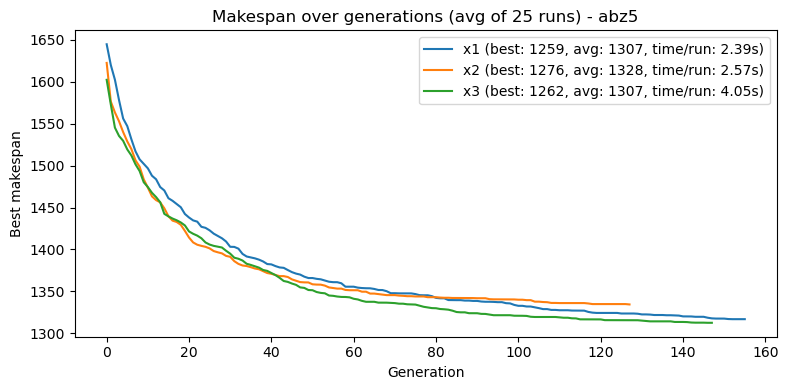


=== Instance abz6 ===
[abz6] Running x1...
[abz6.txt] Run 1 1/25 started...
Stopping early at gen 384 (no improvement for 100 gens)
[abz6.txt] Run 1/25 done. time=4.13s
[abz6.txt] Run 2 2/25 started...
Stopping early at gen 303 (no improvement for 100 gens)
[abz6.txt] Run 2/25 done. time=3.06s
[abz6.txt] Run 3 3/25 started...
Stopping early at gen 280 (no improvement for 100 gens)
[abz6.txt] Run 3/25 done. time=3.02s
[abz6.txt] Run 4 4/25 started...
Stopping early at gen 256 (no improvement for 100 gens)
[abz6.txt] Run 4/25 done. time=2.50s
[abz6.txt] Run 5 5/25 started...
Stopping early at gen 372 (no improvement for 100 gens)
[abz6.txt] Run 5/25 done. time=3.37s
[abz6.txt] Run 6 6/25 started...
Stopping early at gen 139 (no improvement for 100 gens)
[abz6.txt] Run 6/25 done. time=1.25s
[abz6.txt] Run 7 7/25 started...
Stopping early at gen 141 (no improvement for 100 gens)
[abz6.txt] Run 7/25 done. time=1.25s
[abz6.txt] Run 8 8/25 started...
Stopping early at gen 236 (no improvement

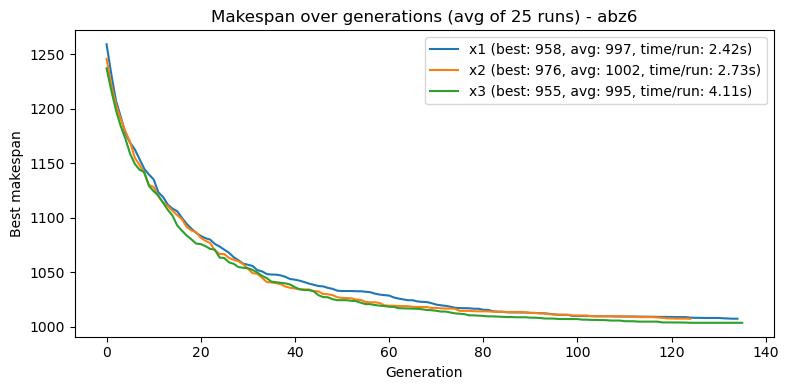


=== Instance abz7 ===
[abz7] Running x1...
[abz7.txt] Run 1 1/25 started...
Stopping early at gen 229 (no improvement for 100 gens)
[abz7.txt] Run 1/25 done. time=5.39s
[abz7.txt] Run 2 2/25 started...
Stopping early at gen 336 (no improvement for 100 gens)
[abz7.txt] Run 2/25 done. time=7.78s
[abz7.txt] Run 3 3/25 started...
Stopping early at gen 163 (no improvement for 100 gens)
[abz7.txt] Run 3/25 done. time=3.79s
[abz7.txt] Run 4 4/25 started...
Stopping early at gen 173 (no improvement for 100 gens)
[abz7.txt] Run 4/25 done. time=4.21s
[abz7.txt] Run 5 5/25 started...
Stopping early at gen 360 (no improvement for 100 gens)
[abz7.txt] Run 5/25 done. time=8.09s
[abz7.txt] Run 6 6/25 started...
[abz7.txt] Run 6/25 done. time=9.04s
[abz7.txt] Run 7 7/25 started...
[abz7.txt] Run 7/25 done. time=9.23s
[abz7.txt] Run 8 8/25 started...
Stopping early at gen 275 (no improvement for 100 gens)
[abz7.txt] Run 8/25 done. time=6.41s
[abz7.txt] Run 9 9/25 started...
[abz7.txt] Run 9/25 done. t

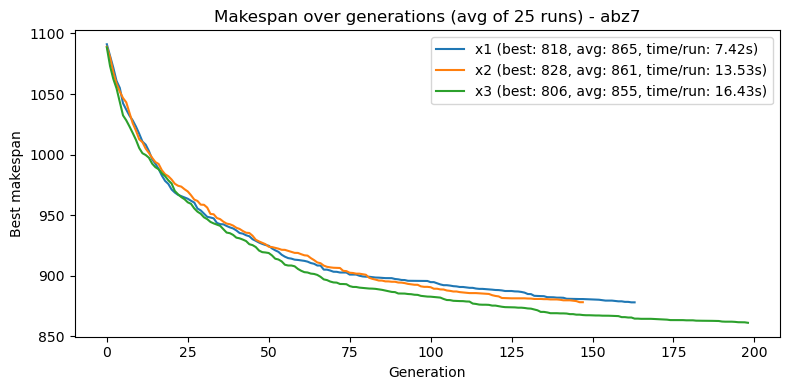

In [193]:
import matplotlib.pyplot as plt

def run_ga_collect_curve(file_path, population_size, generations, mutation_rate, elites, runs=25,
                         adaptive_mutation=True,
                         mutation_min=0.02,
                         mutation_max=0.50,
                         stagnation_generations=25,
                         mutation_increase=1.3,
                         mutation_decrease=0.9,
                         stop_if_stagnant=100):
    num_jobs, num_machines, jobs_data = parse_instance(file_path)
    all_curves = []
    run_times = []           # ADDED
    final_makespans = []     # ADDED

    for run_idx in range(1, runs + 1):
        print(f"[{file_path}] Run {run_idx} {run_idx}/{runs} started...")
        start_time = time()  # ADDED

        population = [
            Individual(generate_chromosome(num_jobs, num_machines))
            for _ in range(population_size)
        ]
        best_curve = []

        current_mutation = mutation_rate
        no_improve = 0
        last_best = None

        stop_no_improve = 0
        stop_last_best = None

        for _gen in range(generations):
            population = population_fitness_sort(population, jobs_data)
            best_curve.append(population[0].fitness)

            if adaptive_mutation:
                if last_best is None or population[0].fitness < last_best:
                    no_improve = 0
                    current_mutation = max(mutation_min, current_mutation * mutation_decrease)
                    last_best = population[0].fitness
                else:
                    no_improve += 1
                    if no_improve >= stagnation_generations:
                        current_mutation = min(mutation_max, current_mutation * mutation_increase)
                        no_improve = 0

            if stop_if_stagnant is not None:
                if stop_last_best is None or population[0].fitness < stop_last_best:
                    stop_last_best = population[0].fitness
                    stop_no_improve = 0
                else:
                    stop_no_improve += 1
                    if stop_no_improve >= stop_if_stagnant:
                        print(f"Stopping early at gen {_gen} (no improvement for {stop_if_stagnant} gens)")
                        break

            new_population = population[:elites]
            while len(new_population) < population_size:
                p1 = tournament_selection(population)
                p2 = tournament_selection(population)
                child = crossover(p1, p2, num_jobs, num_machines)
                child = mutate(child, current_mutation)
                new_population.append(child)

            population = new_population

        elapsed = time() - start_time  # ADDED
        run_times.append(elapsed)      # ADDED
        all_curves.append(best_curve)
        final_makespans.append(best_curve[-1])  # ADDED
        print(f"[{file_path}] Run {run_idx}/{runs} done. time={elapsed:.2f}s")  # ADDED

    avg_curve = [sum(gen_vals) / len(gen_vals) for gen_vals in zip(*all_curves)]
    avg_time_per_run = sum(run_times) / len(run_times) if run_times else 0.0  # ADDED
    return avg_curve, avg_time_per_run, run_times, final_makespans  # CHANGED

# --- Parameter sets (same for all instances) ---
x1 = dict(population_size=300, generations=400, mutation_rate=0.25, elites=8)
x2 = dict(population_size=400, generations=400, mutation_rate=0.25, elites=8)
x3 = dict(population_size=550, generations=400, mutation_rate=0.25, elites=8)


instances = [
    ("abz5.txt", "abz5"),
    ("abz6.txt", "abz6"),
    ("abz7.txt", "abz7"),
]
for path, label in instances:
    print(f"\n=== Instance {label} ===")
    
    print(f"[{label}] Running x1...")
    c1, t1_avg, t1_runs, f1 = run_ga_collect_curve(path, runs=25, **x1)  # CHANGED
    print(f"[{label}] x1 done. Final avg makespan: {c1[-1]:.2f} | best: {min(f1):.2f} | avg: {sum(f1)/len(f1):.2f} | avg time/run: {t1_avg:.2f}s | runs: {t1_runs}")

    print(f"[{label}] Running x2...")
    c2, t2_avg, t2_runs, f2 = run_ga_collect_curve(path, runs=25, **x2)  # CHANGED
    print(f"[{label}] x2 done. Final avg makespan: {c2[-1]:.2f} | best: {min(f2):.2f} | avg: {sum(f2)/len(f2):.2f} | avg time/run: {t2_avg:.2f}s | runs: {t2_runs}")

    print(f"[{label}] Running x3...")
    c3, t3_avg, t3_runs, f3 = run_ga_collect_curve(path, runs=25, **x3)  # CHANGED
    print(f"[{label}] x3 done. Final avg makespan: {c3[-1]:.2f} | best: {min(f3):.2f} | avg: {sum(f3)/len(f3):.2f} | avg time/run: {t3_avg:.2f}s | runs: {t3_runs}")

    plt.figure(figsize=(8, 4))
    plt.plot(c1, label=f"x1 (best: {min(f1):.0f}, avg: {sum(f1)/len(f1):.0f}, time/run: {t1_avg:.2f}s)")
    plt.plot(c2, label=f"x2 (best: {min(f2):.0f}, avg: {sum(f2)/len(f2):.0f}, time/run: {t2_avg:.2f}s)")
    plt.plot(c3, label=f"x3 (best: {min(f3):.0f}, avg: {sum(f3)/len(f3):.0f}, time/run: {t3_avg:.2f}s)")
    plt.title(f"Makespan over generations (avg of 25 runs) - {label}")
    plt.xlabel("Generation")
    plt.ylabel("Best makespan")
    plt.legend()
    plt.tight_layout()
    plt.show()
